In [8]:
import pandas as pd

metrics_segment = pd.read_csv("../outputs/tables/model_metrics_by_segment.csv")

operation_metrics = metrics_segment[
    metrics_segment["segment_col"] == "operation_flag"
].copy()

operation_metrics.sort_values(["segment_value", "mae"])

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
1055,q50,operation_flag,op_abastecimento_bunker,968,35.628178,80.574918,0.974231,15.295337
460,median_by_port_operation,operation_flag,op_abastecimento_bunker,968,37.537999,84.522164,0.982773,10.766667
341,median_by_port,operation_flag,op_abastecimento_bunker,968,38.258945,78.654038,1.004753,23.541667
222,global_median,operation_flag,op_abastecimento_bunker,968,39.389273,81.035648,1.019979,22.383333
698,elasticnet_log_target,operation_flag,op_abastecimento_bunker,968,43.601233,84.036524,1.179044,26.413089
...,...,...,...,...,...,...,...,...
832,random_forest,operation_flag,op_solicitacao_certificado,301,83.683303,130.481216,1.713987,59.609185
951,gradient_boosting,operation_flag,op_solicitacao_certificado,301,102.767177,144.945745,1.818929,76.586608
594,ridge_log_target,operation_flag,op_solicitacao_certificado,301,148.702047,220.127939,2.001638,96.631151
1189,q90,operation_flag,op_solicitacao_certificado,301,160.159620,182.349528,2.260454,146.910784


In [9]:
(
    metrics_segment
    .sort_values(["segment_col", "segment_value", "mae"])
    .groupby(["segment_col", "segment_value"])
    .head(1)
    .reset_index(drop=True)
)

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
0,q50,operation_flag,op_abastecimento_bunker,968,35.628178,80.574918,0.974231,15.295337
1,median_by_port_operation,operation_flag,op_arribada,174,53.099808,115.016140,1.214490,21.025000
2,q50,operation_flag,op_carga,22132,36.833509,79.486293,0.764906,13.922447
3,q50,operation_flag,op_descarga,19822,36.645052,82.040038,0.775139,12.858373
4,q50,operation_flag,op_desembarque_passageiros,884,37.627689,94.652628,1.064369,6.506494
...,...,...,...,...,...,...,...,...
114,global_median,target_range,1 a 2 dias,10836,6.287646,7.272993,0.209226,6.366667
115,global_mean,target_range,2 a 3 dias,5764,11.141712,13.056724,0.210784,11.159926
116,gradient_boosting,target_range,3 a 7 dias,8176,35.793658,45.599683,0.502557,29.971281
117,q95,target_range,acima de 7 dias,3850,119.998028,157.907834,0.480833,92.729407


In [10]:
target_range_metrics = (
    metrics_segment
    [metrics_segment["segment_col"] == "target_range"]
    .sort_values(["segment_value", "mae"])
)

target_range_metrics

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
218,global_median,target_range,1 a 2 dias,10836,6.287646,7.272993,0.209226,6.366667
694,elasticnet_log_target,target_range,1 a 2 dias,10836,11.074503,15.350089,0.356883,8.293014
337,median_by_port,target_range,1 a 2 dias,10836,11.732032,16.083976,0.397485,9.166667
1051,q50,target_range,1 a 2 dias,10836,12.918210,16.827707,0.415920,10.425593
575,ridge_log_target,target_range,1 a 2 dias,10836,15.249395,43.383590,0.452967,10.723051
456,median_by_port_operation,target_range,1 a 2 dias,10836,18.446502,27.978559,0.552815,12.750000
932,gradient_boosting,target_range,1 a 2 dias,10836,31.893012,42.405530,0.698263,23.828964
99,global_mean,target_range,1 a 2 dias,10836,35.159046,35.847247,0.729228,35.684926
813,random_forest,target_range,1 a 2 dias,10836,39.014854,54.971384,0.793000,26.169377
1170,q90,target_range,1 a 2 dias,10836,103.700859,119.136007,1.366380,98.188130


In [11]:
port_metrics = metrics_segment[
    metrics_segment["segment_col"] == "port"
].copy()

(
    port_metrics
    .sort_values("mae", ascending=False)
    .head(30)
)

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
512,ridge_log_target,port,BRMCP,140,548.152550,1033.521813,3.275851,94.710223
188,global_median,port,BRVDC005,30,338.000000,379.595135,2.228919,367.133333
69,global_mean,port,BRVDC005,30,304.848407,350.401224,1.633690,333.981741
1247,q95,port,BRSFS,433,277.178347,301.269710,1.430056,283.723697
1230,q95,port,BRNTR,580,248.923440,262.807877,2.176535,268.277973
1254,q95,port,BRSTM,205,242.705317,264.753394,1.701709,265.156163
1021,q50,port,BRVDC005,30,237.282816,279.185563,0.954878,243.829142
1253,q95,port,BRSSZ,5487,219.133729,242.068278,1.784405,192.610434
664,elasticnet_log_target,port,BRVDC005,30,218.939429,276.403059,0.795034,165.648605
307,median_by_port,port,BRVDC005,30,218.667778,255.966959,0.821894,218.000000


In [12]:
selected_models = [
    "baseline_median_by_port_operation",
    "elasticnet_log_target",
    "gradient_boosting",
]

operation_metrics[
    operation_metrics["model"].isin(selected_models)
].sort_values(["segment_value", "mae"])

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
698,elasticnet_log_target,operation_flag,op_abastecimento_bunker,968,43.601233,84.036524,1.179044,26.413089
936,gradient_boosting,operation_flag,op_abastecimento_bunker,968,54.932842,88.216404,1.244018,37.634400
699,elasticnet_log_target,operation_flag,op_arribada,174,76.457229,129.940290,2.019994,56.068611
937,gradient_boosting,operation_flag,op_arribada,174,110.269316,145.747637,1.953333,86.025878
700,elasticnet_log_target,operation_flag,op_carga,22132,39.794156,81.547004,0.821329,17.209626
938,gradient_boosting,operation_flag,op_carga,22132,41.709795,73.380605,0.849606,24.858984
701,elasticnet_log_target,operation_flag,op_descarga,19822,39.714366,84.731636,0.839069,16.240251
939,gradient_boosting,operation_flag,op_descarga,19822,41.373103,76.039735,0.865400,24.876500
702,elasticnet_log_target,operation_flag,op_desembarque_passageiros,884,46.203763,96.567129,1.246832,21.705671
940,gradient_boosting,operation_flag,op_desembarque_passageiros,884,55.609010,99.183792,1.333195,29.680157


In [13]:
best_by_operation = (
    operation_metrics
    .sort_values(["segment_value", "mae"])
    .groupby("segment_value")
    .head(1)
    .reset_index(drop=True)
)

best_by_operation

,model,segment_col,segment_value,n_rows,mae,rmse,rmsle,medae
0,q50,operation_flag,op_abastecimento_bunker,968,35.628178,80.574918,0.974231,15.295337
1,median_by_port_operation,operation_flag,op_arribada,174,53.099808,115.016140,1.214490,21.025000
2,q50,operation_flag,op_carga,22132,36.833509,79.486293,0.764906,13.922447
3,q50,operation_flag,op_descarga,19822,36.645052,82.040038,0.775139,12.858373
4,q50,operation_flag,op_desembarque_passageiros,884,37.627689,94.652628,1.064369,6.506494
5,q50,operation_flag,op_embarque_passageiros,870,37.803021,95.209665,1.063263,6.315414
6,median_by_port,operation_flag,op_fundeio,459,65.909386,136.574738,1.258050,26.083333
7,median_by_port,operation_flag,op_fundeio_ship_to_ship,97,37.925859,89.050398,0.796776,15.450000
8,median_by_port,operation_flag,op_navio_estado_com_operacao_comercial,114,61.176316,137.986133,1.064259,22.483333
9,median_by_port,operation_flag,op_navio_estado_marinha_brasil,114,61.176316,137.986133,1.064259,22.483333


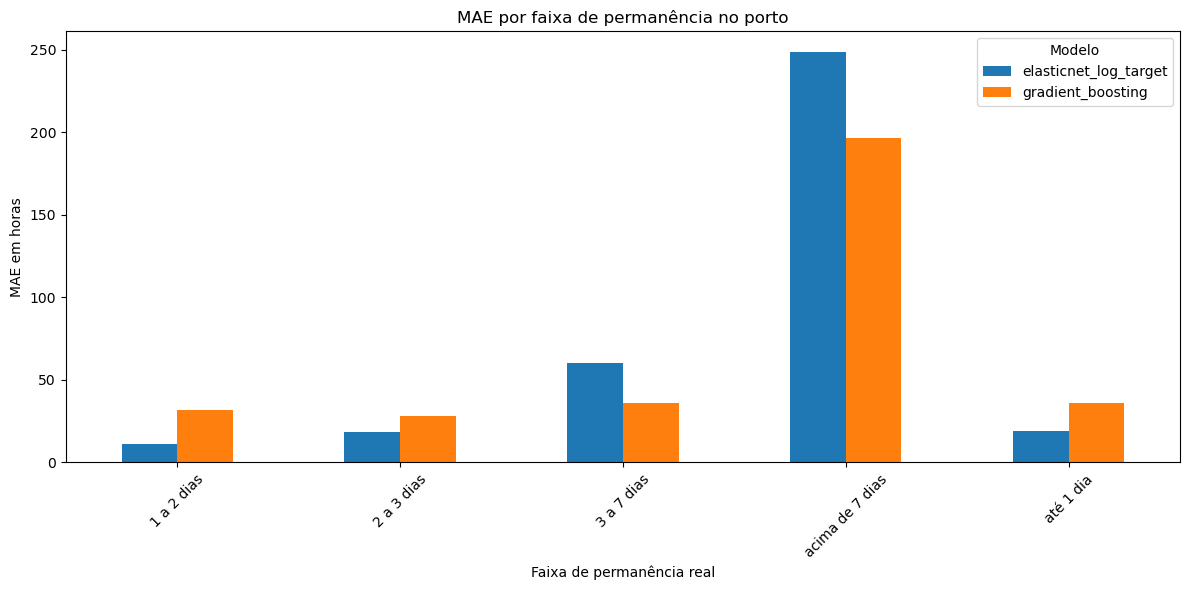

In [14]:
import matplotlib.pyplot as plt

plot_df = target_range_metrics[
    target_range_metrics["model"].isin([
        "baseline_median_by_port_operation",
        "elasticnet_log_target",
        "gradient_boosting",
    ])
].copy()

pivot_df = plot_df.pivot(
    index="segment_value",
    columns="model",
    values="mae",
)

ax = pivot_df.plot(kind="bar", figsize=(12, 6))

ax.set_title("MAE por faixa de permanência no porto")
ax.set_xlabel("Faixa de permanência real")
ax.set_ylabel("MAE em horas")
ax.legend(title="Modelo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()